# 40-year spinup — storage change as % of recharge

For the `40_year_spinup` / `spinup` runs on **wolf2** and **potomac2**, compute annual domain-integrated subsurface storage and express year-to-year change as a percentage of yearly recharge (domain-integrated PME from `pme.pfb`).

Reads yearly `processed_output.nc` files listed in each domain's `file_locations.json` (same pattern as `plot_run.ipynb` and `paper_figures/spinup/storage_timeseries.ipynb`). Files are loaded one year at a time to keep memory use manageable.

Use a kernel with `xarray`, `numpy`, `matplotlib`, and `parflow` (e.g. the `droughts` conda env).

In [7]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import parflow as pf
import pandas as pd
import xarray as xr
from matplotlib.ticker import ScalarFormatter

try:
    from drought_ensemble.analysis.paper_figures import utils
except ImportError:
    def _find_project_root() -> Path:
        for candidate in [Path.cwd(), *Path.cwd().resolve().parents]:
            if (candidate / "classes" / "Domain.py").is_file():
                return candidate
            nested = candidate / "drought-ensemble"
            if (nested / "classes" / "Domain.py").is_file():
                return nested
        raise ImportError(
            "Install the project with `pip install -e .` from drought-ensemble/, "
            "or run this notebook from inside the project tree."
        )

    _root = _find_project_root()
    if str(_root) not in sys.path:
        sys.path.insert(0, str(_root))
    from analysis.paper_figures import utils

PROJECT_ROOT = Path("/glade/derecho/scratch/bwest/drought-ensemble")
ENSEMBLE_NAME = "40_year_spinup"
ENSEMBLE_MEMBER = "spinup"
DOMAINS = ["wolf2", "potomac2"]

HOURS_PER_YEAR = utils.ONE_YEAR
DX = DY = 1000.0


def _format_storage_axis(ax) -> None:
    """Show full storage values; disable matplotlib's misleading +offset ticks."""
    formatter = ScalarFormatter(useOffset=False)
    formatter.set_scientific(False)
    ax.yaxis.set_major_formatter(formatter)

In [8]:
def file_locations_path(domain: str) -> Path:
    return (
        PROJECT_ROOT
        / "domains"
        / domain
        / "processed_full_runs"
        / ENSEMBLE_NAME
        / ENSEMBLE_MEMBER
        / "file_locations.json"
    )


def load_yearly_storage_m3(domain: str) -> np.ndarray:
    """Domain-integrated subsurface storage at the end of each spinup year."""
    files = json.loads(file_locations_path(domain).read_text())
    totals = []
    mask = None

    for i, fpath in enumerate(files, start=1):
        with xr.open_dataset(fpath) as ds:
            if mask is None:
                mask = ds.mask.values > 0
            storage = ds.subsurface_storage.isel(time=-1).values
            totals.append(float(np.nansum(np.where(mask, storage, np.nan))))
        print(f"{domain}: loaded year {i}/{len(files)}", flush=True)

    return np.asarray(totals, dtype=np.float64)


def yearly_recharge_m3(domain: str, sample_nc: str | Path) -> float:
    """Domain-integrated yearly PME (recharge forcing) from pme.pfb."""
    run_dir = Path(sample_nc).parent
    pme_path = run_dir / "pme.pfb"
    if not pme_path.is_file():
        raise FileNotFoundError(f"Missing {pme_path}")

    pme = pf.read_pfb(str(pme_path))
    if pme.ndim != 3:
        raise ValueError(f"Unexpected pme.pfb shape: {pme.shape}")

    with xr.open_dataset(sample_nc) as ds:
        mask_2d = ds.mask.isel(z=0).values > 0

    layer_activity = np.sum(np.abs(pme), axis=(1, 2))
    active_layers = np.where(layer_activity > 0)[0]
    if active_layers.size == 1:
        pme_2d = pme[active_layers[0], :, :]
    else:
        pme_2d = np.sum(pme, axis=0)

    return float(np.sum(np.where(mask_2d, pme_2d, 0.0)) * DX * DY * HOURS_PER_YEAR)


def storage_change_pct_of_recharge(totals_m3: np.ndarray, yearly_recharge_m3: float) -> dict:
    years = np.arange(1, len(totals_m3) + 1, dtype=float)
    delta_m3 = np.diff(totals_m3)
    interval_years = 0.5 * (years[:-1] + years[1:])
    pct = 100.0 * delta_m3 / yearly_recharge_m3
    return {
        "years": years,
        "totals_m3": totals_m3,
        "delta_m3": delta_m3,
        "interval_years": interval_years,
        "pct_of_recharge": pct,
        "yearly_recharge_m3": yearly_recharge_m3,
    }

In [9]:
results = {}
for domain in DOMAINS:
    files = json.loads(file_locations_path(domain).read_text())
    totals = load_yearly_storage_m3(domain)
    recharge = yearly_recharge_m3(domain, files[0])
    results[domain] = storage_change_pct_of_recharge(totals, recharge)
    r = results[domain]
    print(
        f"{domain}: {len(r['years'])} years, "
        f"recharge = {r['yearly_recharge_m3']:,.3e} m³/yr, "
        f"ΔS/recharge = [{r['pct_of_recharge'].min():.3f}%, {r['pct_of_recharge'].max():.3f}%]"
    )

wolf2: loaded year 1/40
wolf2: loaded year 2/40
wolf2: loaded year 3/40
wolf2: loaded year 4/40
wolf2: loaded year 5/40
wolf2: loaded year 6/40
wolf2: loaded year 7/40
wolf2: loaded year 8/40
wolf2: loaded year 9/40
wolf2: loaded year 10/40
wolf2: loaded year 11/40
wolf2: loaded year 12/40
wolf2: loaded year 13/40
wolf2: loaded year 14/40
wolf2: loaded year 15/40
wolf2: loaded year 16/40
wolf2: loaded year 17/40
wolf2: loaded year 18/40
wolf2: loaded year 19/40
wolf2: loaded year 20/40
wolf2: loaded year 21/40
wolf2: loaded year 22/40
wolf2: loaded year 23/40
wolf2: loaded year 24/40
wolf2: loaded year 25/40
wolf2: loaded year 26/40
wolf2: loaded year 27/40
wolf2: loaded year 28/40
wolf2: loaded year 29/40
wolf2: loaded year 30/40
wolf2: loaded year 31/40
wolf2: loaded year 32/40
wolf2: loaded year 33/40
wolf2: loaded year 34/40
wolf2: loaded year 35/40
wolf2: loaded year 36/40
wolf2: loaded year 37/40
wolf2: loaded year 38/40
wolf2: loaded year 39/40
wolf2: loaded year 40/40
wolf2: 40

In [10]:
summary_rows = []
for domain, r in results.items():
    summary_rows.append(
        {
            "domain": domain,
            "spinup_years": len(r["years"]),
            "yearly_recharge_m3": r["yearly_recharge_m3"],
            "final_storage_m3": r["totals_m3"][-1],
            "final_delta_m3": r["delta_m3"][-1],
            "final_pct_of_recharge": r["pct_of_recharge"][-1],
            "mean_abs_pct_last_5y": np.mean(np.abs(r["pct_of_recharge"][-5:])),
        }
    )

summary = pd.DataFrame(summary_rows).set_index("domain")
summary

,spinup_years,yearly_recharge_m3,final_storage_m3,final_delta_m3,final_pct_of_recharge,mean_abs_pct_last_5y
domain,,,,,,
wolf2,40,8.966321e+08,2.010985e+11,-3.394203e+05,-0.037855,0.047347
potomac2,40,1.522757e+09,4.259687e+11,-1.856999e+06,-0.121950,0.159155


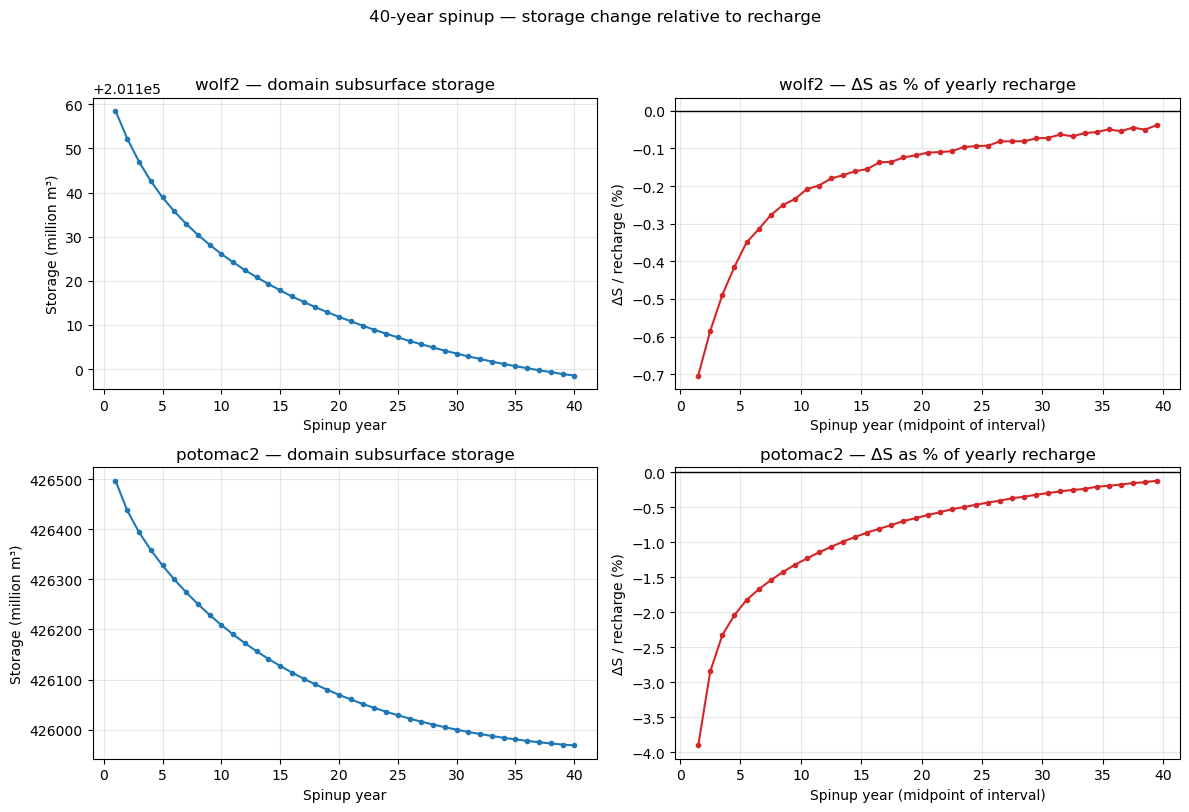

In [11]:
fig, axes = plt.subplots(len(DOMAINS), 2, figsize=(12, 4 * len(DOMAINS)), sharex=False)
if len(DOMAINS) == 1:
    axes = np.array([axes])

for ax_row, domain in zip(axes, DOMAINS):
    r = results[domain]
    total_storage_mm3 = r["totals_m3"] / 1e6

    ax_row[0].plot(r["years"], total_storage_mm3, "o-", ms=3)
    _format_storage_axis(ax_row[0])
    ax_row[0].set_title(f"{domain} — domain subsurface storage")
    ax_row[0].set_xlabel("Spinup year")
    ax_row[0].set_ylabel("Storage (million m³)")
    ax_row[0].grid(True, alpha=0.3)

    ax_row[1].plot(r["interval_years"], r["pct_of_recharge"], "o-", ms=3, color="C3")
    ax_row[1].axhline(0.0, color="k", lw=1)
    ax_row[1].set_title(f"{domain} — ΔS as % of yearly recharge")
    ax_row[1].set_xlabel("Spinup year (midpoint of interval)")
    ax_row[1].set_ylabel("ΔS / recharge (%)")
    ax_row[1].grid(True, alpha=0.3)

fig.suptitle("40-year spinup — storage change relative to recharge", y=1.01)
fig.tight_layout()
plt.show()

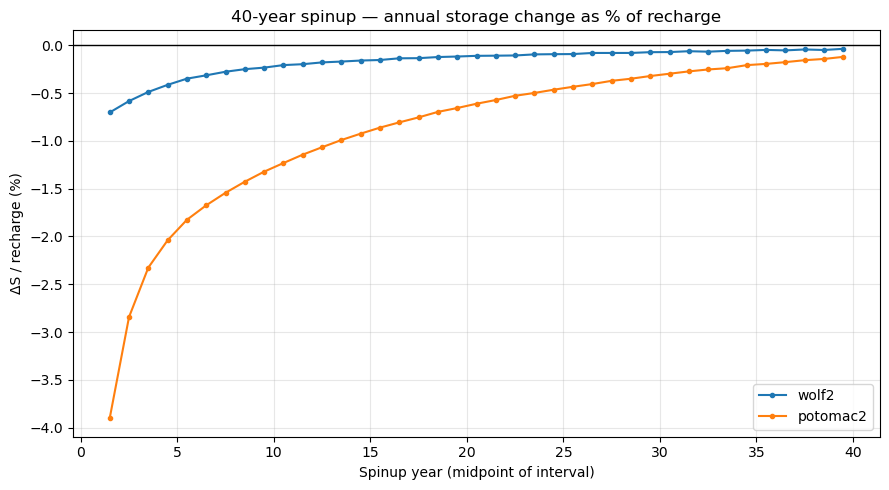

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
for domain in DOMAINS:
    r = results[domain]
    ax.plot(r["interval_years"], r["pct_of_recharge"], "o-", ms=3, label=domain)

ax.axhline(0.0, color="k", lw=1)
ax.set_xlabel("Spinup year (midpoint of interval)")
ax.set_ylabel("ΔS / recharge (%)")
ax.set_title("40-year spinup — annual storage change as % of recharge")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()